# **LIMPIEZA DE TEXTO**

In [ ]:
#pip install python-dotenv
#pip install openai
#pip install spacy unidecode
#python -m spacy download es_core_news_sm
#pip install fonttools
#pip install -q textblob
#pip install spacy
#python -m spacy download es_core_news_sm
#pip install wordcloud
#pip install ufal.udpipe
#pip install pyspellchecker
#wget https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-3131/spanish-gsd-ud-2.5-191206.udpipe
#python -m spacy download es_core_news_sm
#python -m spacy download es_core_news_md
#pip install igraph

In [ ]:
from textblob import TextBlob
import spacy
nlp = spacy.load("es_core_news_sm")
from dotenv import load_dotenv
import openai
import os
import re
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import networkx as nx
from collections import Counter
import matplotlib.pyplot as plt
import nltk
import numpy as np
nltk.download('stopwords')
nltk.download('words')
import pandas as pd
import unicodedata
nltk.download('punkt')
import random
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, bartlett, pearsonr
import community
from wordcloud import WordCloud
from nltk.probability import FreqDist
import subprocess
import pickle
import igraph as ig
import unidecode
from itertools import combinations
from tqdm import tqdm
nltk.download('punkt_tab')
from openai import OpenAI
import math
from spellchecker import SpellChecker
from unidecode import unidecode
import sys

In [3]:
#FUNCIONES DE LIMPIEZA DE TEXTO
def limpiar_texto(texto):
    # Convertir texto a minúsculas
    texto = texto.lower()

    # Quitar caracteres especiales y números
    texto = re.sub(r'[^a-zA-ZñÑáéíóúÁÉÍÓÚó\s]', '', texto)
    texto = ''.join((c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn'))

    return texto

def quitar_stopwords(texto):
    # Tokenizar el texto
    tokens = word_tokenize(texto)

    # Quitar stopwords
    texto_limpio = [word for word in tokens if word not in stop_words]

    return ' '.join(texto_limpio)


def generar_skipgramas(texto, n=2, k=2):
    tokens = word_tokenize(texto)
    skipgramas = []
    for i in range(len(tokens)):
        for j in range(i + 1, min(i + k + 2, len(tokens))):
            skipgramas.append((tokens[i], tokens[j]))

    return skipgramas


def eliminar_palabras_cortas(texto):
    excepciones = {"up", "fé", "fe"}  # palabras que no queremos eliminar como UP(unión patriótica) y fe
    palabras = texto.split()
    palabras_filtradas = [
        palabra for palabra in palabras
        if len(palabra) > 2 or palabra.lower() in excepciones
    ]
    texto_filtrado = ' '.join(palabras_filtradas)
    return texto_filtrado

In [ ]:
carpeta = 'C:/Users/Desktop/caso_03sub'
textos_huila = []
textos_antioquia = []
textos_meta = []
textos_nsantander = []
textos_ccaribe = []
textos_casanare = []
textos_otros = []

for archivo in os.listdir(carpeta):
    if archivo.endswith('.txt'):
        ruta_archivo = os.path.join(carpeta, archivo)
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()

        nombre = archivo.lower()

        if nombre.startswith('huila'):
            textos_huila.append((archivo, contenido))
        elif nombre.startswith('antioquia'):
            textos_antioquia.append((archivo, contenido))
        elif nombre.startswith('meta'):
            textos_meta.append((archivo, contenido))
        elif nombre.startswith('norte'):
            textos_nsantander.append((archivo, contenido))
        elif nombre.startswith('costa'):
            textos_ccaribe.append((archivo, contenido))
        elif nombre.startswith('casanare'):
            textos_casanare.append((archivo, contenido))
        else:
            textos_otros.append((archivo, contenido))

# Unir textos
texto_huila = ' '.join([contenido for _, contenido in textos_huila])
texto_antioquia = ' '.join([contenido for _, contenido in textos_antioquia])
texto_meta = ' '.join([contenido for _, contenido in textos_meta])
texto_nsantander = ' '.join([contenido for _, contenido in textos_nsantander])
texto_ccaribe = ' '.join([contenido for _, contenido in textos_ccaribe])
texto_casanare = ' '.join([contenido for _, contenido in textos_casanare])

print(f"Archivos de Subcaso Huila: {len(textos_huila)}")
print(f"Archivos de Subcaso Antioquia: {len(textos_antioquia)}")
print(f"Archivos de Subcaso Meta: {len(textos_meta)}")
print(f"Archivos de Subcaso Norte de Santander: {len(textos_nsantander)}")
print(f"Archivos de Subcaso Costa Caribe: {len(textos_ccaribe)}")
print(f"Archivos de Subcaso Casanare: {len(textos_casanare)}")
print(f"Otros archivos: {len(textos_otros)}")


Archivos de Subcaso Huila: 178
Archivos de Subcaso Antioquia: 5
Archivos de Subcaso Meta: 3
Archivos de Subcaso Norte de Santander: 10
Archivos de Subcaso Costa Caribe: 10
Archivos de Subcaso Casanare: 91
Otros archivos: 0


# **TEXTO COMPLETO PARA DEPURACIÓN y CREAR DICCIONARIO**

In [ ]:
texto_total = ' '.join(contenido for lista in [textos_huila,textos_antioquia,textos_meta,textos_nsantander,textos_ccaribe,textos_casanare]
    for _, contenido in lista)

In [ ]:
##Eliminamos las palabras cortas no necesarias
texto1= eliminar_palabras_cortas(texto_total)
#Primera lematización
lematizaciones = {}
with open('C:/Users/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

palabras = texto1.split()
palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
texto_filtrado = ' '.join(palabras_lematizadas)
tokens = nltk.word_tokenize(texto_filtrado, language="spanish")

# LEMATIZAR modelo spicy:
nlp = spacy.load("es_core_news_md", disable=["parser","ner"])
excepciones = {"soldado", "voluntario"}

def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser","ner"])
        for token_original, doc in zip(bloque, docs):
            token_spacy = doc[0]
            if token_original.lower() in excepciones:
                lemas.append(token_original.lower())
            else:
                lemas.append(token_spacy.lemma_)

    return lemas
lemas = lematizar_en_bloques(tokens, bloque_size=10000)

In [ ]:
# VERIFICAR SI ESTAN EN UN DICCIONARIO Y CLASIFICAR LAS PALABRAS
spell = SpellChecker(language="es")

def limpiar_y_revisar(lemas):
    limpios = []
    typos = []

    for lema in lemas:
        palabra = lema.lower().strip()
        palabra = re.sub(r"[0-9]", "", palabra)
        if not palabra:
            continue
        if len(palabra) <= 2:
            continue
        if palabra in spell:
            limpios.append(palabra)
        else:
            typos.append(palabra)

    return limpios, typos
lemas_limpios, posibles_typos = limpiar_y_revisar(lemas)
print("Lemas válidos:", len(lemas_limpios))
print("Posibles typos:", len(posibles_typos))

In [ ]:
# Primera depuración de las palabras identificadas como typo
print(sys.getdefaultencoding())

os.environ["OPENAI_API_KEY"] = ""
client = OpenAI()
PromptInicio = (
    "Utilizando la lista de palabras proporcionada a continuación, "
    "extrae únicamente las palabras que NO pertenecen al idioma español "
    "y que parecen errores o ruido de subtítulos automáticos. "
    "No marques como errores las palabras correctas en español, "
    "aunque sean poco frecuentes.\n\n[Inicio lista]\n"
)
PromptFinal = "\n[Fin lista]\n\nResponde únicamente con una lista de los posibles errores."

def revisar_con_gpt(palabras, bloque_size=500):
    resultados = []
    n_bloques = math.ceil(len(palabras) / bloque_size)

    for i in range(n_bloques):
        bloque = palabras[i*bloque_size:(i+1)*bloque_size]
        lista_str = "\n".join(bloque)

        prompt = PromptInicio + lista_str + PromptFinal

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "Eres un asistente lingüístico experto en español."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        salida = response.choices[0].message.content.strip()
        resultados.append(salida)

        print(f"Bloque {i+1}/{n_bloques} procesado")

    return resultados

errores_detectados = revisar_con_gpt(posibles_typos, bloque_size=300)
ruta_errores = "C:/Users/Downloads/errores_detectados.txt" 
with open(ruta_errores, "w", encoding="utf-8") as f:
    for bloque in errores_detectados:
        f.write(bloque + "\n")

In [ ]:
# Cargar el archivo depurado previamente para depurarlo
ruta_archivo = "C:/Users/Downloads/errores_detectados.txt" 
with open(ruta_archivo, "r", encoding="utf-8") as f:
    lineas = f.readlines()

lineas_limpias = [linea.lstrip("- ").strip() for linea in lineas]
client = OpenAI()

# Prompt para corrección y lematización
PromptInicio_corr = (
    "A partir de la lista de palabras proporcionada a continuación, "
    "propón una corrección para cada palabra y redúcela a su raíz más pequeña (lema). "
    "Si la palabra no tiene significado o no se puede corregir, responde con 'NA'.\n\n"
    "[Inicio lista]\n")

PromptFinal_corr = (
    "\n[Fin lista]\n\n"
    "Responde únicamente en el formato:\n"
    "palabra_original - correccion")

def corregir_y_lematizar(palabras, bloque_size=300):
    resultados = []
    n_bloques = math.ceil(len(palabras) / bloque_size)

    for i in range(n_bloques):
        bloque = palabras[i*bloque_size:(i+1)*bloque_size]
        lista_str = "\n".join(bloque)

        prompt = PromptInicio_corr + lista_str + PromptFinal_corr

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "Eres un asistente experto en lingüística y lematización del español."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        salida = response.choices[0].message.content.strip()
        resultados.append(salida)

        print(f"Bloque {i+1}/{n_bloques} procesado")

    # Unir todos los bloques 
    texto_resultado = "\n".join(resultados)
    pares = [line.strip() for line in texto_resultado.splitlines() if "-" in line]
    data = [line.split("-", 1) for line in pares]
    df = pd.DataFrame(data, columns=["original", "correccion"])
    df["original"] = df["original"].str.strip()
    df["correccion"] = df["correccion"].str.strip()

    return df
df_correcciones = corregir_y_lematizar(lineas_limpias, bloque_size=100)

# Guardar en un archivo
df_correcciones.to_csv("correcciones.csv", index=False, encoding="utf-8")

ruta = "C:/Users/Downloads/correcciones.txt" 
with open(ruta, "w", encoding="utf-8") as f:
    for _, row in df_correcciones.iterrows():
        f.write(f"{row['original']} : {row['correccion']}\n")

In [ ]:
# Remover palabras repetidas y guardar el archivo final:
ruta_entrada = ruta
ruta_salida = "C:/Users/Desktop/Casos_JEP/Casos_JEP/salida_03.txt"
with open(ruta_entrada, "r", encoding="utf-8") as f:
    lineas = f.readlines()
unicas = list(dict.fromkeys(lineas))
with open(ruta_salida, "w", encoding="utf-8") as f:
    f.writelines(unicas)

# **Diccionario ejecuciones extrajudiciales**

In [ ]:
def normalizar(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = unicodedata.normalize("NFD", texto)
    texto = "".join(c for c in texto if unicodedata.category(c) != "Mn")
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

# Diccionario
ruta_excel_ex = "C:/Users/Desktop/Casos_JEP/material_adicional/Lexicon_ejecuciones_extrajudiciales.xlsx"
ejecuciones_ex = pd.read_excel(ruta_excel_ex, engine="openpyxl")


textos = {
    "texto1": texto_huila,
    "texto2": texto_antioquia,
    "texto3": texto_meta,
    "texto4": texto_nsantander,
    "texto5": texto_ccaribe,
    "texto6": texto_casanare,
}
textos_norm = {k: normalizar(v) for k, v in textos.items()}

# contar freq por palabras
words = ejecuciones_ex["Word"].dropna().astype(str).apply(normalizar).tolist()

resultados = []
for w in words:
    fila = {"Word_norm": w}
    patron = r"\b" + r"\s+".join(map(re.escape, w.split())) + r"\b"
    for nombre, texto in textos_norm.items():
        fila[nombre] = len(re.findall(patron, texto))
    resultados.append(fila)

df_frecuencias = pd.DataFrame(resultados)

ejecuciones_ex["Word_norm"] = ejecuciones_ex["Word"].apply(normalizar)

df_merge = df_frecuencias.merge(
    ejecuciones_ex[["Word_norm", "Victima", "Victimario", "Testigo", "Métodos"]],
    on="Word_norm",how="left")

# Calcular scores por texto y rol
textos_cols = list(textos.keys())
roles = ["Victima", "Victimario", "Testigo", "Métodos"]

tabla_roles_wide = pd.DataFrame([
    {"Texto": t, "Rol": r, "Score": (df_merge[t] * df_merge[r]).sum()}
    for t in textos_cols
    for r in roles
]).pivot(index="Texto", columns="Rol", values="Score")

tabla_roles_wide

Rol,Métodos,Testigo,Victima,Victimario
Texto,,,,
texto1,416418.0,412219.0,417839.0,633575.0
texto2,11651.0,16589.0,20767.0,18677.0
texto3,4620.0,7900.0,8132.0,8303.0
texto4,6919.0,8947.0,11146.0,11233.0
texto5,14545.0,17766.0,23029.0,21061.0
texto6,205165.0,201200.0,217069.0,312251.0


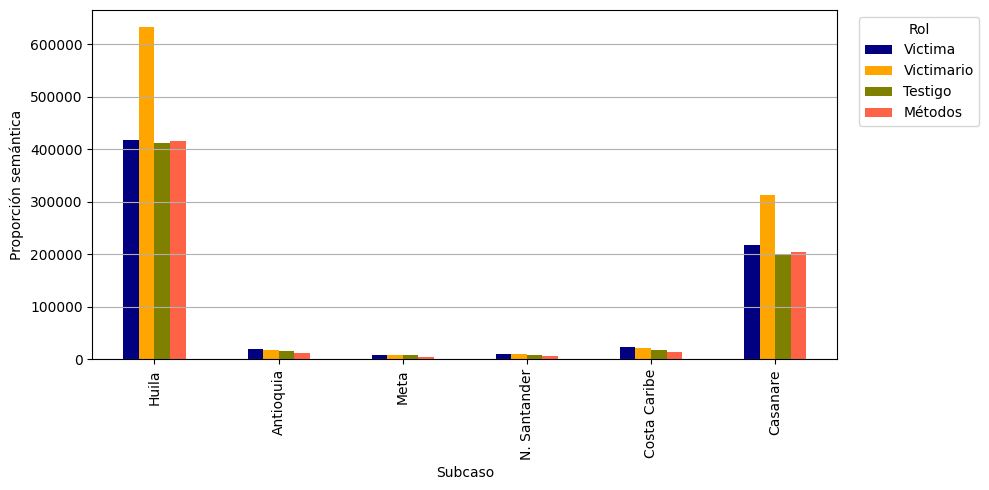

In [ ]:
mapa_nombres = {"texto1": "Huila","texto2": "Antioquia","texto3": "Meta","texto4": "N. Santander",
    "texto5": "Costa Caribe","texto6": "Casanare"}
tabla_norm = tabla_roles_wide.copy()
tabla_norm = tabla_norm.rename(index=mapa_nombres)

roles = ["Victima", "Victimario", "Testigo", "Métodos"]
colores = {"Victima": "navy","Victimario": "orange", "Testigo": "olive", "Métodos": "tomato"}

ax = tabla_norm[roles].plot(kind="bar",figsize=(10,5),color=[colores[r] for r in roles])
plt.ylabel("Proporción semántica")
plt.xlabel("Subcaso")
plt.grid(axis="y")
plt.legend(title="Rol", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

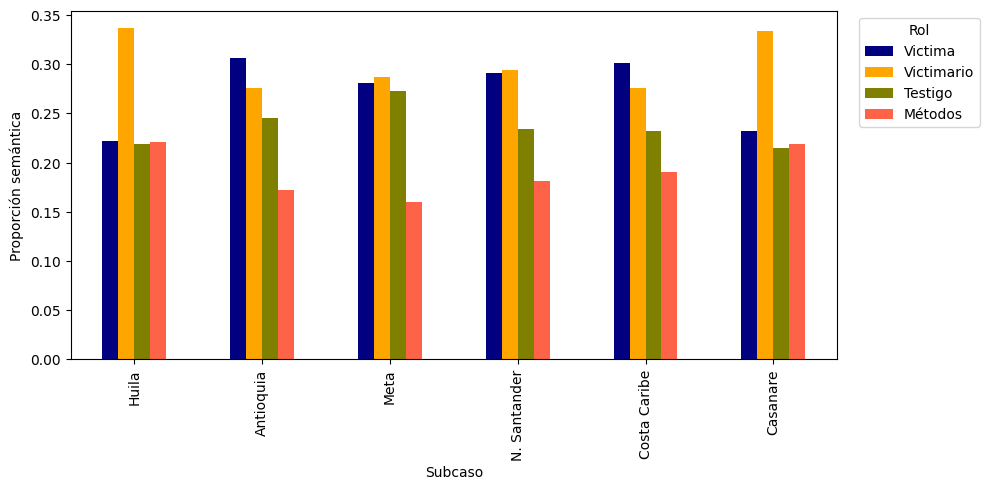

In [ ]:
mapa_nombres = {"texto1": "Huila", "texto2": "Antioquia","texto3": "Meta", "texto4": "N. Santander", "texto5": "Costa Caribe",
   "texto6": "Casanare"}
tabla_norm = tabla_roles_wide.copy()
tabla_norm = tabla_norm.rename(index=mapa_nombres)

roles = ["Victima", "Victimario", "Testigo", "Métodos"]
tabla_norm[roles] = tabla_norm[roles].div(tabla_norm[roles].sum(axis=1), axis=0)

roles = ["Victima", "Victimario", "Testigo", "Métodos"]
colores = {"Victima": "navy","Victimario": "orange", "Testigo": "olive", "Métodos": "tomato"}

ax = tabla_norm[roles].plot(kind="bar",figsize=(10,5),color=[colores[r] for r in roles])

plt.ylabel("Proporción semántica")
plt.xlabel("Subcaso")
#plt.grid(axis="y")
plt.legend(title="Rol", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


# **Análisis de texto por subcaso**

In [ ]:
#------------------------- Primera lematización --------------------------
lematizaciones = {}
with open('C:/Users/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

def aplicar_lematizacion(texto, lematizaciones):
    palabras = texto.split()
    palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
    return ' '.join(palabras_lematizadas)

textos = {
    'Huila': texto_huila,
    'Antioquia': texto_antioquia,
    'Costa Caribe': texto_ccaribe,
    'Casanare': texto_casanare,
    'N. Santander': texto_nsantander,
    'Meta' : texto_meta}

textos_lematizados = {}

for nombre, texto in textos.items():
    textos_lematizados[nombre] = aplicar_lematizacion(texto, lematizaciones)

texto_huila_lem = textos_lematizados['Huila']
texto_antioquia_lem = textos_lematizados['Antioquia']
texto_ccaribe_lem = textos_lematizados['Costa Caribe']
texto_casanare_lem = textos_lematizados['Casanare']
texto_nsantander_lem = textos_lematizados['N. Santander']
texto_meta_lem = textos_lematizados['Meta']

#----------------Eliminar palabras cortas:---------------------
texto_huila_final = eliminar_palabras_cortas(texto_huila_lem)
texto_antioquia_final = eliminar_palabras_cortas(texto_antioquia_lem)
texto_ccaribe_final = eliminar_palabras_cortas(texto_ccaribe_lem)
texto_casanare_final = eliminar_palabras_cortas(texto_casanare_lem)
texto_nsantander_final = eliminar_palabras_cortas(texto_nsantander_lem)
texto_meta_final = eliminar_palabras_cortas(texto_meta_lem)


#------------------------Tokenizar---------------------------------
textos = {
    'Antioquia': texto_antioquia_final,
    'Costa Caribe': texto_ccaribe_final,
    'Casanare': texto_casanare_final,
    'N. Santander': texto_nsantander_final,
    'Meta': texto_meta_final,
    'Huila': texto_huila_final}

tokens_dict = {}
for nombre, texto in textos.items():
    tokens = nltk.word_tokenize(texto, language="spanish")
    tokens_dict[nombre] = tokens

# **LEMATIZACIÓN Y CORRECCIÓN PREVIA**

In [ ]:
#-------------------------Lematización spacy-----------------------------------------------
# palabras que NO deben lematizarse 
excepciones = {"voluntaria", "soldado", "rio sucio", "tierralta", "carepa", "unguía", "unguia"}
nlp = spacy.load("es_core_news_md", disable=["parser", "ner"])

def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser", "ner"])
        for tok_original, doc in zip(bloque, docs):
            token_spacy = doc[0]
            if tok_original.lower() in excepciones:
                lemas.append(tok_original.lower())
            else:
                lemas.append(token_spacy.lemma_)
    return lemas

lemas_dict = {}
for nombre, tokens in tokens_dict.items():
    print(f"\n Texto: {nombre} ({len(tokens)} tokens)")
    lemas_dict[nombre] = lematizar_en_bloques(tokens, bloque_size=10000)

In [ ]:
# -----------------------------Unir el texto -----------------------------------------------
textos_lemas = {
    nombre: " ".join(lemas_dict[nombre])
    for nombre in ['Antioquia','Costa Caribe','Casanare','N. Santander','Meta','Huila']}

#-----------------------emplear lematizacion anterior:--------------------------------------
lematizaciones2 = {}
with open('C:/Users/Desktop/Casos_JEP/salida_03.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones2[palabra.strip()] = lema.strip()
textos_finales_dicc = {}

for nombre, texto in textos_lemas.items():
    palabras = texto.split()

    texto_lemas_dicc = []
    for palabra in palabras:
        if palabra in lematizaciones2:
            if lematizaciones2[palabra] != "NA":
                texto_lemas_dicc.append(lematizaciones2[palabra])  # usar el lema corregido
            # si es "NA", no se agrega nada (se elimina)
        else:
            texto_lemas_dicc.append(palabra)  # si no está en el diccionario, se deja igual

    texto_final = " ".join(texto_lemas_dicc)
    textos_finales_dicc[nombre] = texto_final

# **GENERAR SKIPGRAMAS**

In [ ]:
def eliminar_acentos(palabra):
    return ''.join((c for c in unicodedata.normalize('NFD', palabra) if unicodedata.category(c) != 'Mn'))

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto

# ---------------------------- stopwords ---------------------------------
stop_words = set(stopwords.words('spanish'))

archivo_stopwords = 'C:/Users/Desktop/Casos_JEP/stop_words_espanol.txt'
with open(archivo_stopwords, 'r', encoding='utf-8') as f:
    for linea in f:
        word = linea.strip()
        stop_words.add(word)
        for palabra in linea.split():
            stop_words.add(eliminar_acentos(palabra.lower()))

ruta_palabras = "C:/Users/Desktop/Casos_JEP/palabras_no_validas.txt"
with open(ruta_palabras, "r", encoding="utf-8") as f:
    palabras_no_validas = [line.strip() for line in f if line.strip()]

ruta_lemas = "C:/Users/Desktop/Casos_JEP/lemas_lemas.txt"
lemas_set = set()
lematizaciones_final = {}
with open(ruta_lemas, "r", encoding="utf-8") as f:
    for linea in f:
        if ":" in linea:
            palabra, lema = linea.strip().split(":", 1)
            lemas_set.add(palabra.strip())
            lematizaciones_final[normalizar(palabra.strip())] = normalizar(lema.strip())

filtradas = [p for p in palabras_no_validas if p not in lemas_set]

textos_finales_limpios = {}
for nombre, texto_final in textos_finales_dicc.items():
    textos_finales_limpios[nombre] = limpiar_texto(texto_final)

# -------------------------- Lematizar ---------------------------------------------
textos_lema_dicc = {}
for nombre, texto_final_limpio in textos_finales_limpios.items():
    palabras = texto_final_limpio.split()
    palabras_lematizadas = [lematizaciones_final.get(palabra, palabra) for palabra in palabras]
    textos_lema_dicc[nombre] = " ".join(palabras_lematizadas)


textos_filtrados = {}
for nombre, texto_lema in textos_lema_dicc.items():
    palabras = texto_lema.split()
    textos_filtrados[nombre] = " ".join([p for p in palabras if p not in filtradas])

# ----------------       Generar skipgramas  ----------------------------
textos_skipgramas = {}
for nombre, texto_filtrado in textos_lema_dicc.items():
    texto_sin_stopwords = quitar_stopwords(texto_filtrado)
    tokens = word_tokenize(texto_sin_stopwords)
    frec = Counter(tokens)
    tokens_filtrados = [t for t in tokens if frec[t] > 1]
    texto_dep = " ".join(tokens_filtrados)
    skipgramas = generar_skipgramas(texto_dep, 2, 2)
    textos_skipgramas[nombre] = {
        "texto_sin_stopwords": texto_dep,
        "skipgramas": skipgramas
    }

In [ ]:
##---------- Filtrar skipgramas ----------------------------
textos_skipgramas_filtrados = {}

for nombre, datos in textos_skipgramas.items():
    skipgramas = datos["skipgramas"]

    # 1.Eliminar bucles (a, a)
    skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
    conteo = Counter(skipgramas_sin_bucles)
    # 2.Conservar solo los skipgramas con frecuencia > 1
    skipgramas_filtrados = [b for b, f in conteo.items() if f > 1]
    textos_skipgramas_filtrados[nombre] = {
        "texto_sin_stopwords": datos["texto_sin_stopwords"],
        "skipgramas_filtrados": skipgramas_filtrados,
        "frecuencias": conteo}

#-------------calcular frecuencias-------------------------------
tablas_frecuencias = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    conteo = datos["frecuencias"]
    conteo_str = {' '.join(k): v for k, v in conteo.items() if v > 1}
    df_top = pd.DataFrame(Counter(conteo_str).most_common(10), columns=["Skipgrama", "Frecuencia"])
    tablas_frecuencias[nombre] = df_top

    print(f"\nTop 10 skipgramas en '{nombre}':")
    display(df_top)


Top 10 skipgramas en 'Antioquia':


,Skipgrama,Frecuencia
0,jurisdiccion especial,77
1,especial paz,77
2,jurisdiccion paz,75
3,ejercito nacional,66
4,oriente antioquia,63
5,presentar combatir,61
6,derecho humano,56
7,audiencia publico,51
8,falso positivo,49
9,desaparicion forzar,47



Top 10 skipgramas en 'Costa Caribe':


,Skipgrama,Frecuencia
0,batallon popa,183
1,jurisdiccion especial,96
2,especial paz,93
3,jurisdiccion paz,89
4,presentar combatir,88
5,desaparicion forzar,85
6,asesinato desaparicion,70
7,pueblo indigena,66
8,resolucion conclusion,61
9,reconocimiento responsabilidad,61



Top 10 skipgramas en 'Casanare':


...

,Skipgrama,Frecuencia
0,norte santander,67
1,desaparicion forzar,65
2,brigada movil,63
3,crimen guerra,62
4,crimen humanidad,58
5,reconocer responsabilidad,55
6,audiencia publico,52
7,presentar combatir,51
8,crimen lesa,51
9,especial paz,46



Top 10 skipgramas en 'Meta':


,Skipgrama,Frecuencia
0,juan carlos,33
1,juan rodriguez,31
2,carlos rodriguez,31
3,jurisdiccion paz,30
4,jurisdiccion especial,29
5,especial paz,28
6,version voluntario,25
7,justicia reparar,24
8,desaparicion forzar,23
9,ministerio publico,22



Top 10 skipgramas en 'Huila':


,Skipgrama,Frecuencia
0,comandante batallon,8865
1,comandante peloton,4198
2,batallon comandante,3523
3,ordenar operacion,3495
4,seccion inteligencia,3197
5,comandante brigada,3064
6,batallon magdalena,3056
7,comandante compania,2553
8,grupo especial,2465
9,oficial operacion,2206


In [ ]:
##Guardamaos cada texto depurado para el modelo LDA::
ruta = "C:/Users/Desktop/Casos_JEP/textos_depurados_final/caso_03"
os.makedirs(ruta, exist_ok=True)
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    nombre_limpio = nombre.replace(" ", "_")
    ruta_archivo = os.path.join(ruta,
        f"texto_sin_stopwords_{nombre_limpio}.txt")
    with open(ruta_archivo, "w", encoding="utf-8") as f:
        f.write(texto)

# **ANÁLISIS DESCRIPTIVO**

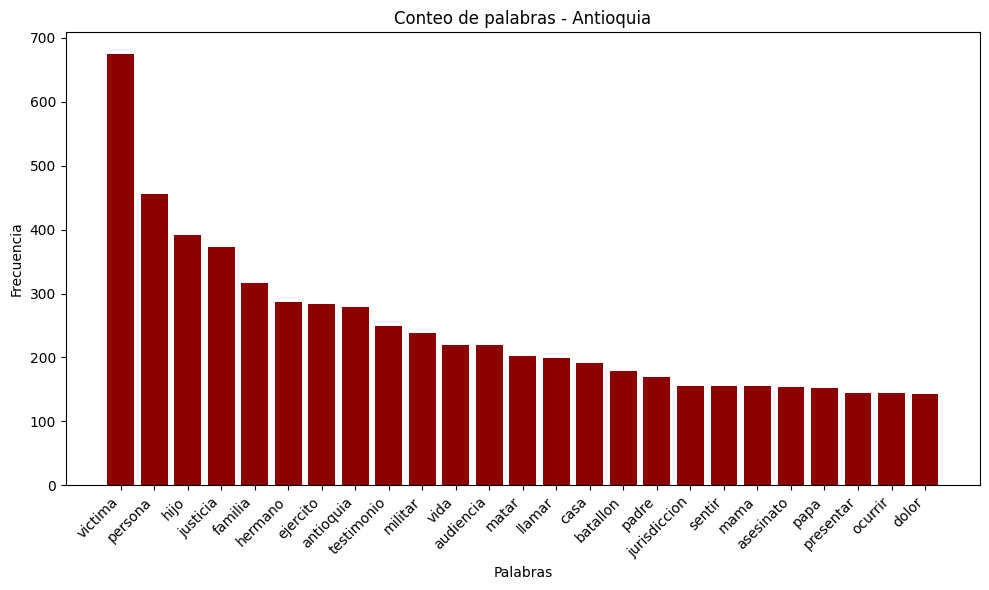

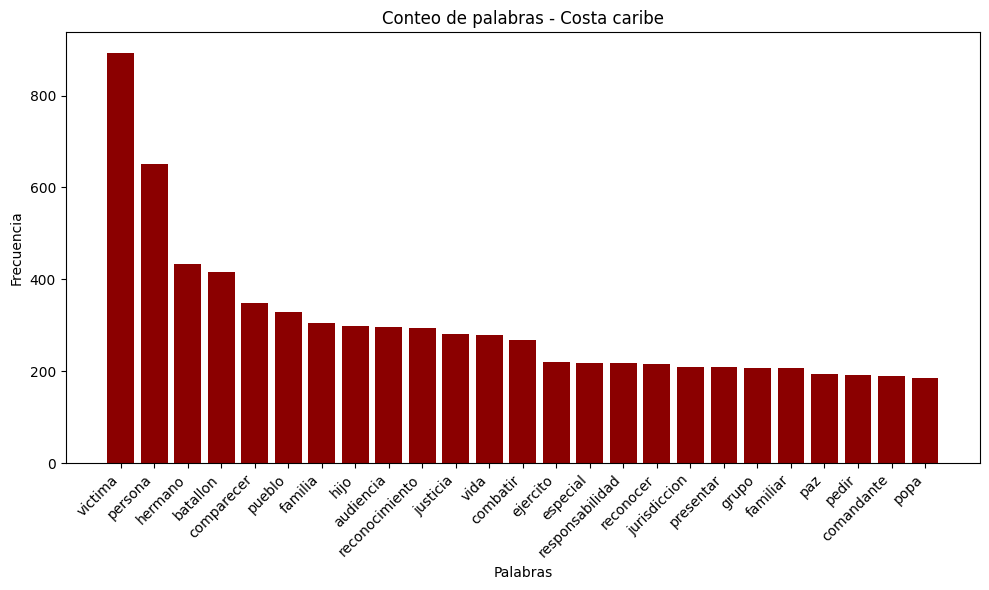

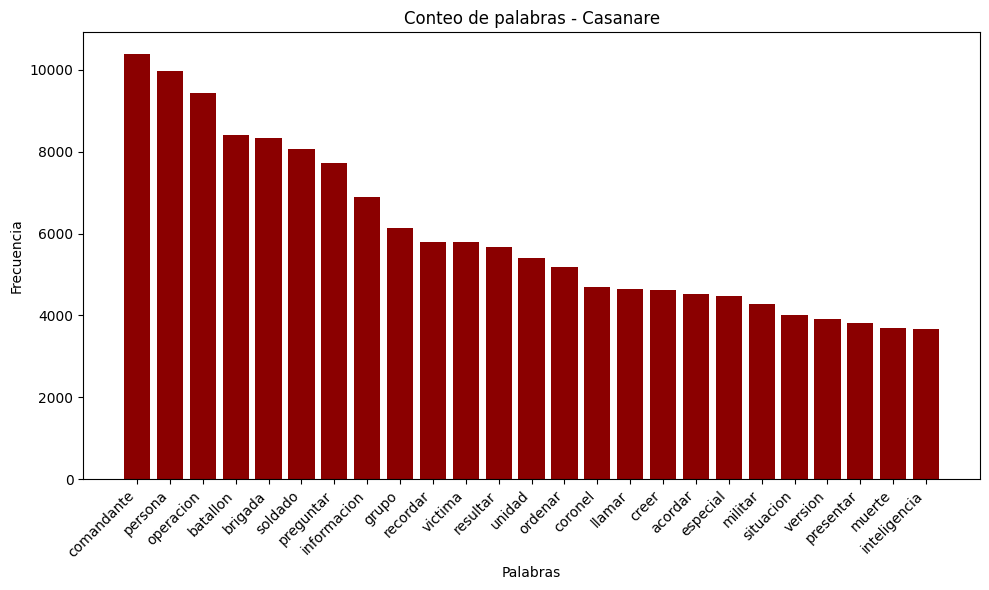

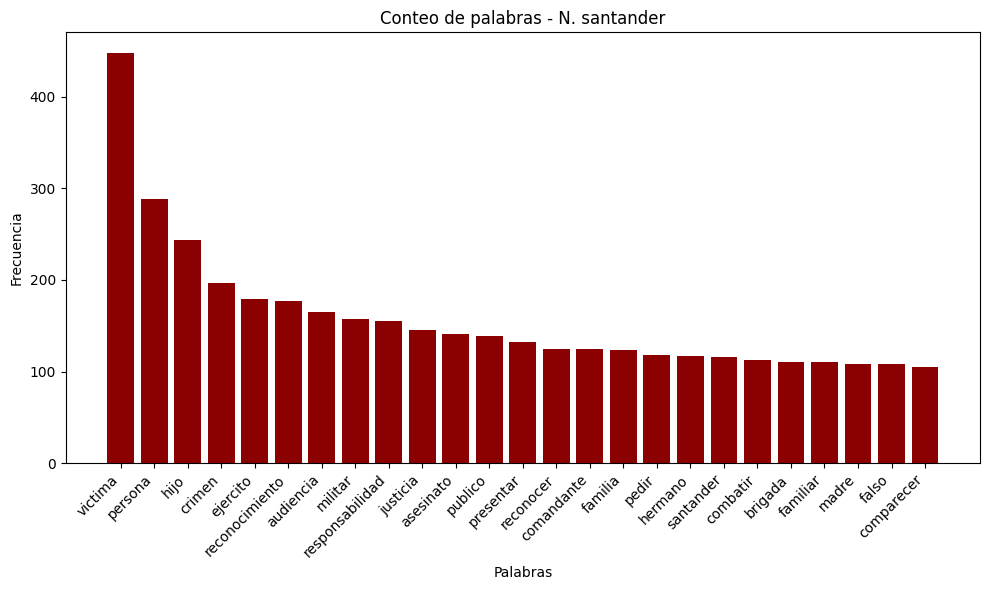

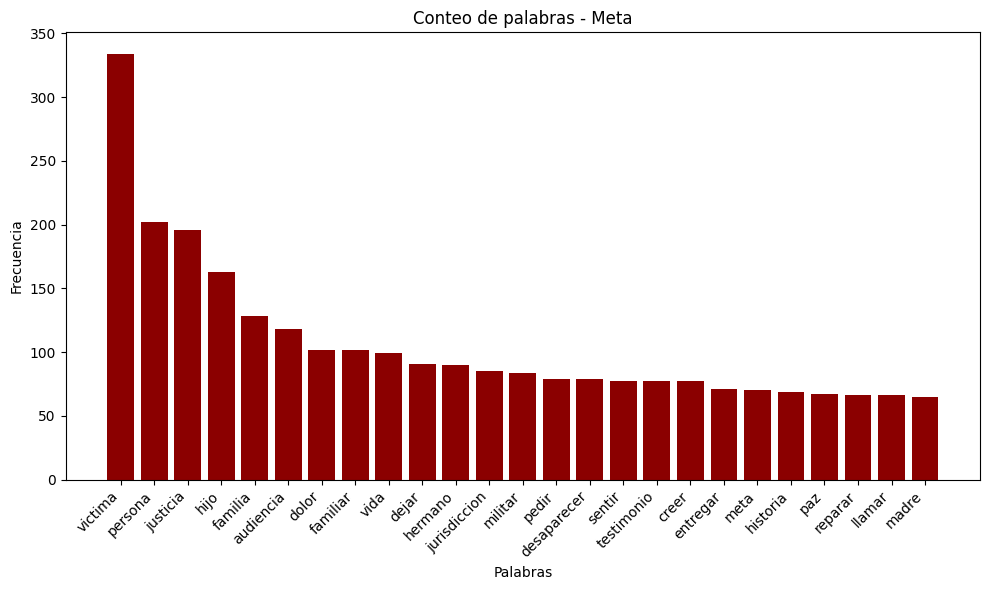

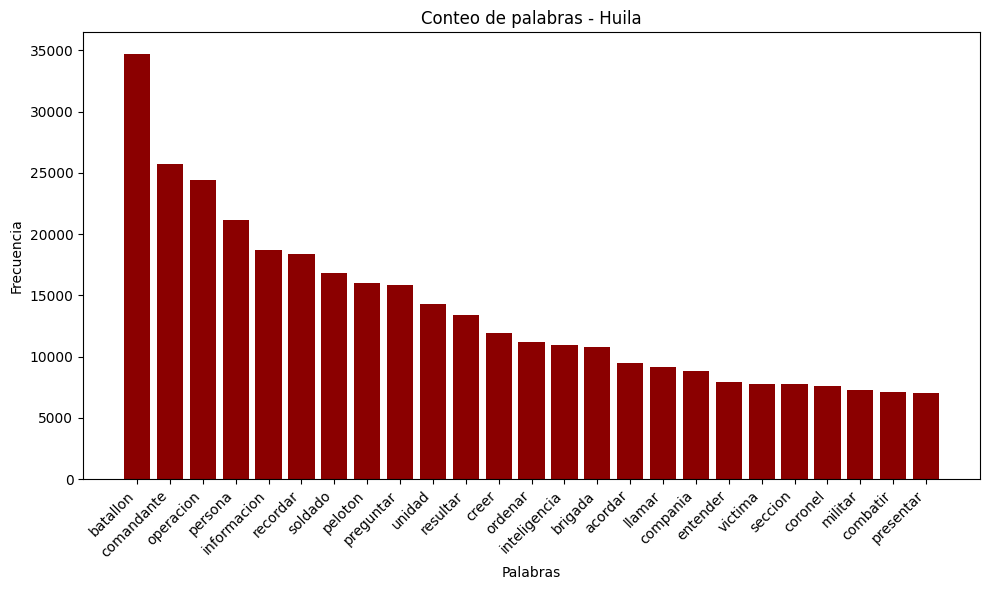

In [ ]:
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(25)
    palabras, frecuencias = zip(*palabras_repetidas)

    plt.figure(figsize=(10, 6))
    plt.bar(palabras, frecuencias, color="darkred")
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.title(f"Conteo de palabras - {nombre.capitalize()}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
##Frecuencia de palabras por subanálisis:
tablas_frecuencias = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(15)

    tabla_frecuencias = pd.DataFrame(palabras_repetidas, columns=['Palabra', 'Frecuencia'])
    tablas_frecuencias[nombre] = tabla_frecuencias

    print(f"\n Frecuencias para: {nombre}")
    print(tabla_frecuencias)

tabla_final = pd.concat(tablas_frecuencias, names=['Grupo']).reset_index(level=0)
tabla_final.reset_index(drop=True, inplace=True)



 Frecuencias para: Antioquia
       Palabra  Frecuencia
0      victima         675
1      persona         455
2         hijo         392
3     justicia         373
4      familia         316
5      hermano         286
6     ejercito         283
7    antioquia         279
8   testimonio         249
9      militar         238
10        vida         220
11   audiencia         219
12       matar         202
13      llamar         199
14        casa         191

 Frecuencias para: Costa Caribe
           Palabra  Frecuencia
0          victima         893
1          persona         651
2          hermano         433
3         batallon         416
4       comparecer         348
5           pueblo         328
6          familia         306
7             hijo         298
8        audiencia         297
9   reconocimiento         294
10        justicia         282
11            vida         279
12        combatir         268
13        ejercito         220
14        especial         219

 Frecuen

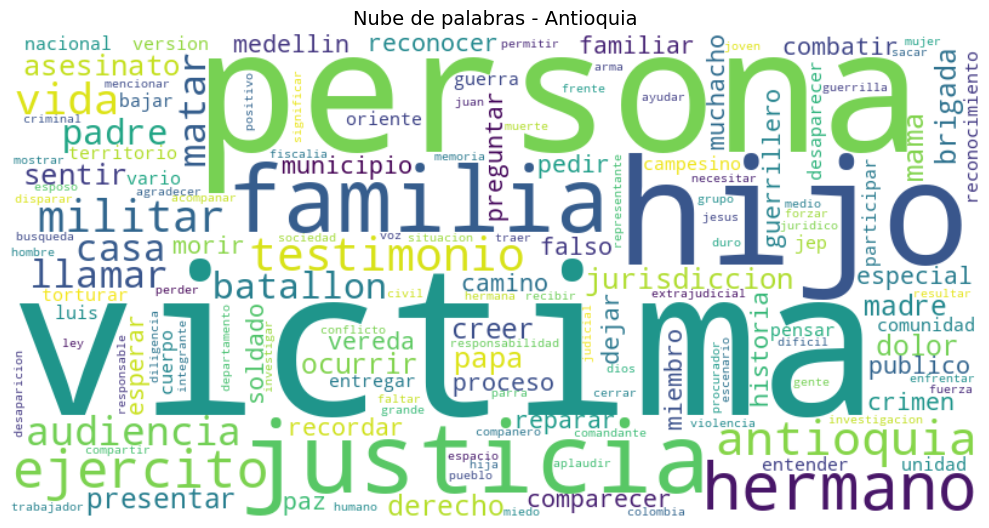

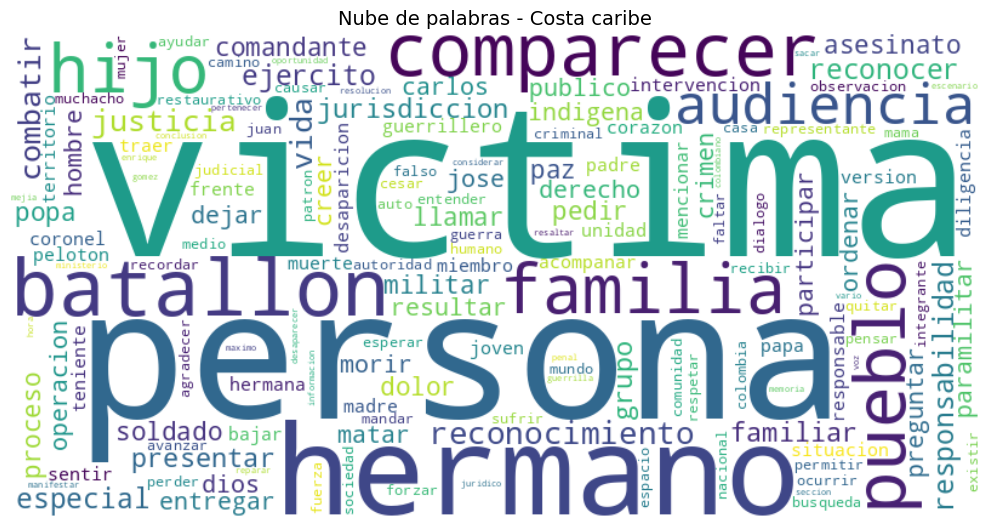

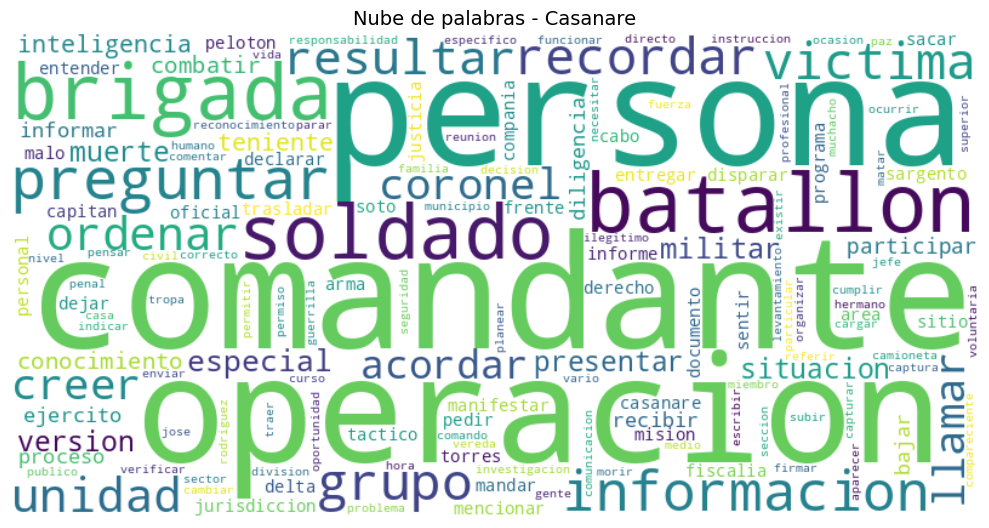

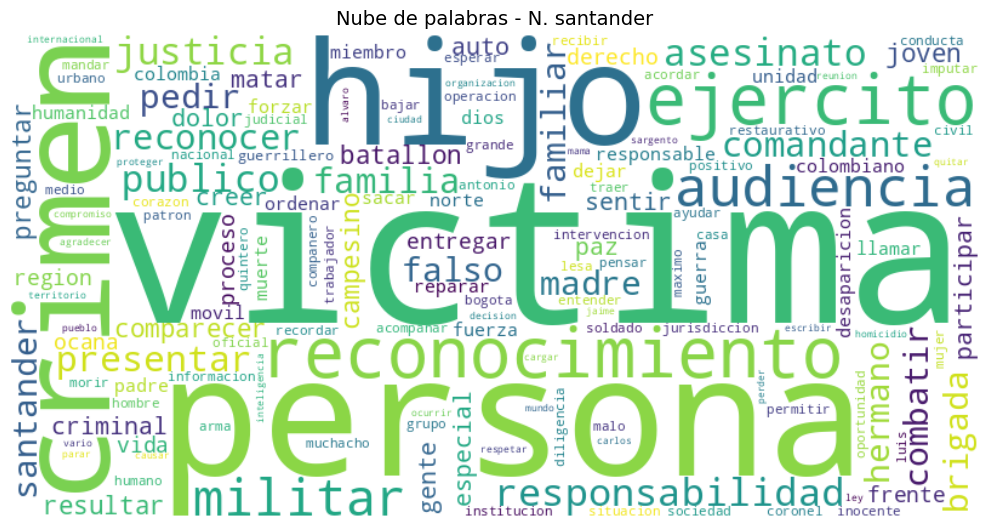

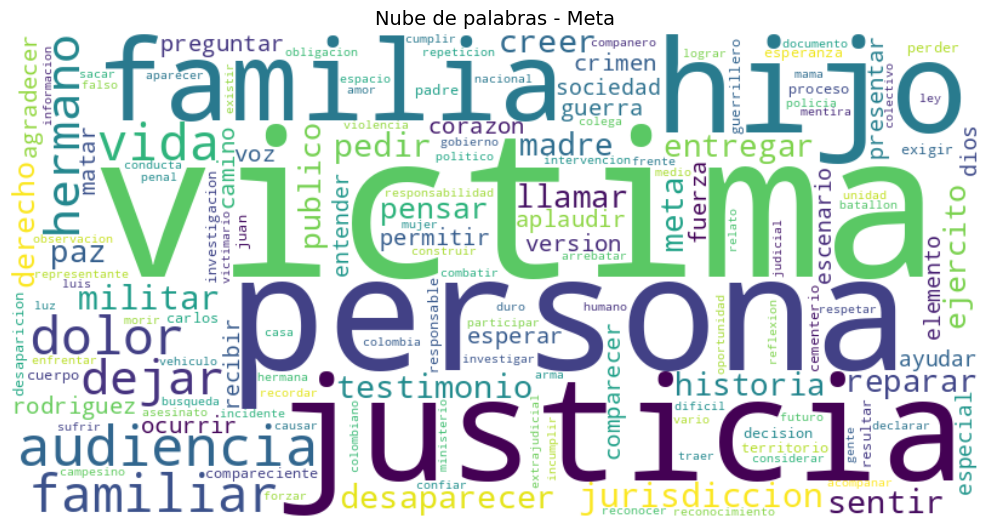

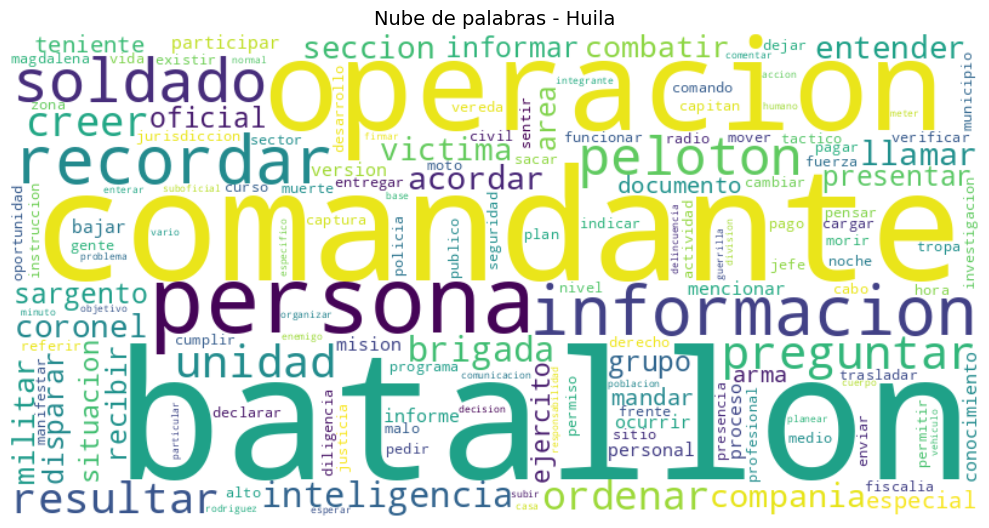

In [ ]:
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)

    nube = WordCloud(width=800, height=400,
        background_color='white',
        max_words=150
    ).generate_from_frequencies(frecuencia_palabras)

    plt.figure(figsize=(10, 6))
    plt.imshow(nube, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nube de palabras - {nombre.capitalize()}", fontsize=14)
    plt.tight_layout()
    plt.show()



# **ANÁLISIS DE SENTIMIENTO**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

ruta_excel = "C:/Users/Desktop/Casos_JEP/emociones.xlsx"
lexico = pd.read_excel(ruta_excel, engine="openpyxl")
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})

lexico['Palabra'] = (
    lexico['Palabra'].astype(str).str.lower().str.strip().apply(unidecode).str.replace(r'[^a-zñáéíóúü\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True))

columnas_emociones = [
    'Positive','Negative','Anger','Anticipation','Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico[columnas_emociones] = lexico[columnas_emociones].fillna(0).astype(int)
lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()
emociones = lexico.set_index('Palabra').to_dict(orient='index')


resultados = []
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]

    # Normalizar
    tokens = [ re.sub(r'\s+', ' ',re.sub(r'[^a-zñáéíóúü\s]', '',
                      unidecode(t.lower().strip())))
        for t in word_tokenize(texto)]

    conteo = Counter({emo: 0 for emo in columnas_emociones})

    for token in tokens:
        if token in emociones:
            for emo, valor in emociones[token].items():
                conteo[emo] += valor

    conteo['Texto'] = nombre
    resultados.append(conteo)

df_emociones = pd.DataFrame(resultados)
df_emociones = df_emociones[['Texto'] + columnas_emociones]

# Traducir nombres de columnas
df_emociones = df_emociones.rename(columns={'Positive': 'Positivo','Negative': 'Negativo','Anger': 'Ira',
    'Anticipation': 'Anticipación','Disgust': 'Disgusto','Fear': 'Miedo','Joy': 'Alegría','Sadness': 'Tristeza',
    'Surprise': 'Sorpresa', 'Trust': 'Confianza'})
print(df_emociones)

          Texto  Positivo  Negativo     Ira  Anticipación  Disgusto   Miedo  \
0     Antioquia      7687      5793    3616          2944      1876    4569   
1  Costa Caribe      9908      6687    4374          3473      2245    5380   
2      Casanare    150257     87135   55481         45776     23807   80942   
3  N. Santander      5097      3646    2392          1902      1448    2838   
4          Meta      3392      2433    1402          1405       796    1984   
5         Huila    313235    152593  121096         85825     36070  165046   

   Alegría  Tristeza  Sorpresa  Confianza  
0     2010      3680      1571       5356  
1     2389      4410      1709       6880  
2    29679     49825     21821     112380  
3     1250      2308       950       3500  
4      985      1634       724       2555  
5    57302     82516     37810     235977  


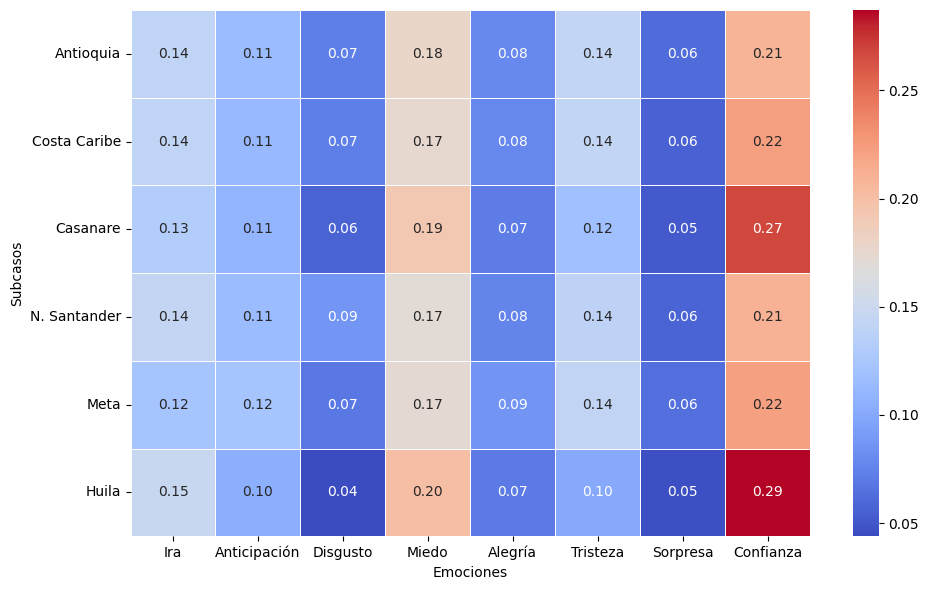

In [ ]:
#Mapa de calor de emociones
columnas_emociones = ["Ira" , "Anticipación" , "Disgusto" ,  "Miedo",  "Alegría" , "Tristeza" , "Sorpresa", "Confianza"]
df_heatmap = df_emociones[['Texto'] + columnas_emociones].copy()
df_heatmap.set_index('Texto', inplace=True)
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0)

plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap_norm, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.xlabel('Emociones')
plt.ylabel('Subcasos')
plt.tight_layout()
plt.show()


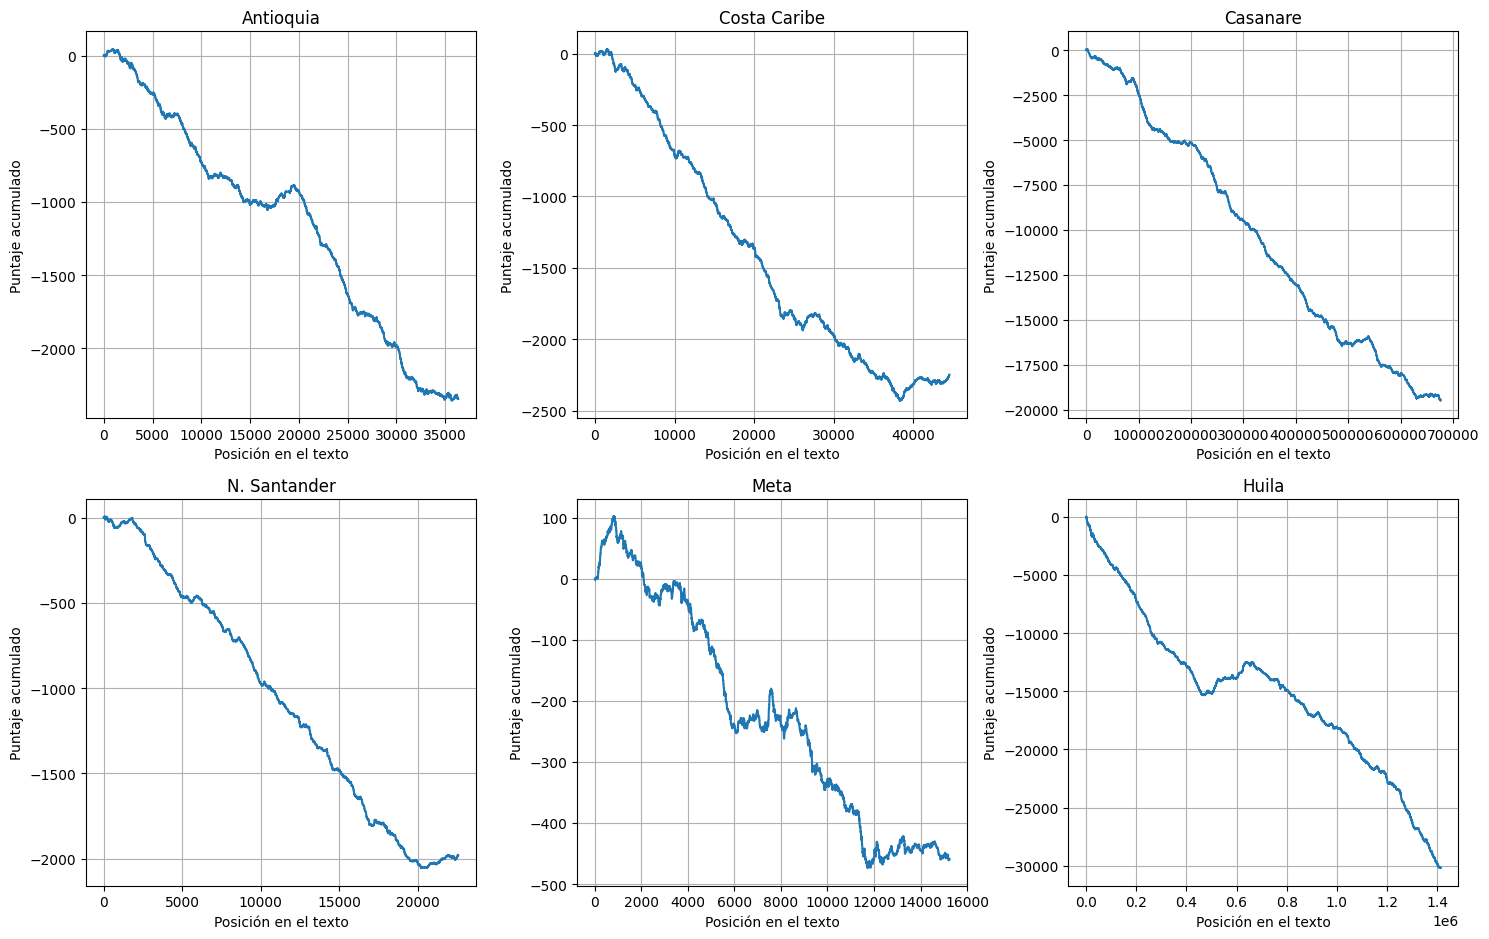

In [ ]:
##Grafico de sentimiento acumulado mediante diccionario AFINN

afinn = pd.read_csv("C:/Users/Desktop/Casos_JEP/material_adicional/lexico_afinn.csv")
afinn['palabra'] = afinn['palabra'].str.lower().str.strip()
afinn_dict = dict(zip(afinn['palabra'], afinn['puntuacion']))

tendencias_afinn = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = [
        unidecode(t.lower().strip())
        for t in word_tokenize(texto)]
    puntajes = [
        afinn_dict.get(token, 0)
        for token in tokens]

    df = pd.DataFrame({"palabra": tokens, "puntaje": puntajes})
    df["sentimiento_acumulado"] = df["puntaje"].cumsum()
    tendencias_afinn[nombre] = df

n = len(tendencias_afinn)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5* nrows))
axes = axes.flatten()

for ax, (nombre, df) in zip(axes, tendencias_afinn.items()):
    ax.plot(df.index, df["sentimiento_acumulado"])
    ax.set_title(f"{nombre}")
    ax.set_xlabel("Posición en el texto")
    ax.set_ylabel("Puntaje acumulado")
    ax.grid(True)

for i in range(len(tendencias_afinn), len(axes)):
    axes[i].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



# **RED BASICA**

In [ ]:
## Componente gigante para las redes de cada subcaso (región)
def get_gigante(G):
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()

# ----------------------- Cálculo de métricas ---------------------------------
redes_metrics = {}
centralidades_por_red = {}
top10_grado_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    skipgramas = datos["skipgramas_filtrados"]

    G = nx.Graph()
    G.add_edges_from(skipgramas)

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = get_gigante(G)

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente gigante muy pequeña.")
        continue

    # Métricas básicas
    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())

    # Top 10 por grado
    top10_grado = (
        pd.DataFrame(grados.items(), columns=["nodo", "grado"])
        .sort_values("grado", ascending=False)
        .head(10)
        .assign(porcentaje_grado=lambda x: x["grado"] / (2 * num_aristas))
    )
    top10_grado_por_red[nombre] = top10_grado

    # Centralidades
    nodos = list(G_gigante.nodes())
    betweenness = nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42)
    closeness = nx.closeness_centrality(G_gigante)
    eigenvector = nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6)

    df_centralidad = pd.DataFrame({
        "nodo": nodos,
        "grado": [grados[n] for n in nodos],
        "betweenness": [betweenness[n] for n in nodos],
        "closeness": [closeness[n] for n in nodos],
        "eigenvector": [eigenvector[n] for n in nodos]
    })
    centralidades_por_red[nombre] = df_centralidad

    redes_metrics[nombre] = {
        "num_nodos": num_nodos,
        "num_aristas": num_aristas,
        "densidad": nx.density(G_gigante),
        "grado_promedio": sum(grados.values()) / num_nodos,
        "transitividad_global": nx.transitivity(G_gigante),
        "assortatividad_grado": nx.degree_assortativity_coefficient(G_gigante),
        "diametro": nx.diameter(G_gigante),
        "longitud_media_camino": nx.average_shortest_path_length(G_gigante),
        "betweenness_media": df_centralidad["betweenness"].mean(),
        "betweenness_max": df_centralidad["betweenness"].max(),
        "closeness_media": df_centralidad["closeness"].mean(),
        "eigenvector_media": df_centralidad["eigenvector"].mean(),
        "grado_max": top10_grado["grado"].max(),
        "grado_medio_top10": top10_grado["grado"].mean(),
        "concentracion_top10": top10_grado["grado"].sum() / (2 * num_aristas),
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print("\nMétricas")
print(df_metrics)

Grafo 'Antioquia': 1973 nodos, 13363 aristas (componente gigante).
Grafo 'Costa Caribe': 2089 nodos, 16105 aristas (componente gigante).
Grafo 'Casanare': 6449 nodos, 176616 aristas (componente gigante).
Grafo 'N. Santander': 1523 nodos, 10152 aristas (componente gigante).
Grafo 'Meta': 1247 nodos, 5340 aristas (componente gigante).
Grafo 'Huila': 8305 nodos, 295255 aristas (componente gigante).

Métricas
              num_nodos  num_aristas  densidad  grado_promedio  \
Antioquia          1973        13363  0.006869       13.545869   
Costa Caribe       2089        16105  0.007385       15.418861   
Casanare           6449       176616  0.008495       54.773143   
N. Santander       1523        10152  0.008759       13.331582   
Meta               1247         5340  0.006874        8.564555   
Huila              8305       295255  0.008562       71.102950   

              transitividad_global  assortatividad_grado  diametro  \
Antioquia                 0.155855             -0.132850  

In [ ]:
#Primeras 10 palabras con mayor grado:
top10_grado_por_red

{'Antioquia':            nodo  grado  porcentaje_grado
 27      victima    500          0.018708
 0       persona    361          0.013507
 103    justicia    303          0.011337
 47         hijo    293          0.010963
 170     familia    248          0.009279
 51      hermano    226          0.008456
 57     ejercito    218          0.008157
 41    antioquia    216          0.008082
 467  testimonio    214          0.008007
 350        vida    211          0.007895,
 'Costa Caribe':                nodo  grado  porcentaje_grado
 14          victima    617          0.019156
 115         persona    467          0.014499
 290         hermano    332          0.010307
 10         batallon    282          0.008755
 25       comparecer    276          0.008569
 152          pueblo    252          0.007824
 436         familia    247          0.007668
 22   reconocimiento    238          0.007389
 572            vida    236          0.007327
 148        justicia    231          0.007172,
 